## Task 4: Latent Space Analysis and Error Inspection

This notebook covers the analysis of the model's internal feature representation, the application and comparison of dimensionality reduction techniques and the inspection of misclassified samples.

In [1]:
import torch
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [2]:
class TransferResNet50(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super().__init__()

        # Load pretrained ResNet50
        self.base_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        # Remove the final fully connected layer
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()

        # Freeze all layers in the base model
        for param in self.base_model.parameters():
            param.requires_grad = False

        # New classification head
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        features = self.base_model(x)
        output = self.classifier(features)
        return output

### 1. Load the trained model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = TransferResNet50(dropout_rate=0.5)
model.load_state_dict(torch.load("resnet50_transfer_finetuned.pth", map_location=device))
model = model.to(device)
model.eval()
# remove the last 2 layers to have the latent representation in output
last_layers = model.classifier[2:]
model.classifier = model.classifier[:2]

Using device: cpu


### 2. Extract latent representations

In [4]:
def to_3_channels(x):
    """
    Converts grayscale images to 3 channels by repeating the channel dimension.
    Expected input shape: (N, H, W, 1) or (N, 1, H, W) or (N, H, W)
    Output shape: (N, 3, H, W)
    """
    if x.ndim == 3:  # (N, H, W)
        x = np.expand_dims(x, axis=-1)

    if x.shape[-1] == 1:  # (N, H, W, 1)
        x = np.transpose(x, (0, 3, 1, 2))  # -> (N, 1, H, W)

    if x.shape[1] == 1:  # (N, 1, H, W)
        x = np.repeat(x, 3, axis=1)  # -> (N, 3, H, W)

    return x.astype(np.float32)

X_test = to_3_channels(np.load("X_test.npy"))
y_test = np.load("y_test.npy")

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 16
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

all_latents = []
all_truth_labels = []
all_pred_labels = []
all_pred_conf = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        all_latents.append(outputs.cpu().numpy())
        all_truth_labels.append(labels.cpu().numpy())
        confidence = torch.sigmoid(last_layers(outputs))
        pred_labels = (confidence > 0.5).float()
        all_pred_labels.append(pred_labels.cpu().numpy())
        all_pred_conf.append(confidence.cpu().numpy())

all_latents = np.concatenate(all_latents, axis=0)
all_truth_labels = np.concatenate(all_truth_labels, axis=0)
all_pred_labels = np.concatenate(all_pred_labels, axis=0).squeeze()
all_pred_conf = np.concatenate(all_pred_conf, axis=0).squeeze()

print(all_latents[:5])
print()
print(all_truth_labels[:5])
print()
print(all_pred_labels[:5])
print()
print(all_pred_conf[:5])

[[0.6344211  0.         0.         ... 1.2433612  0.         0.        ]
 [1.1090063  0.         0.19459048 ... 1.3865858  0.01658706 0.05830282]
 [0.74256986 0.48251843 1.1143148  ... 0.37920815 0.44842798 0.37245354]
 [0.8875862  0.         0.         ... 1.7386745  0.         0.        ]
 [1.144541   0.         0.         ... 1.1832286  0.         0.13242769]]

[0. 0. 0. 0. 0.]

[0. 0. 0. 0. 0.]

[0.00068263 0.00024032 0.16658543 0.00020992 0.00033124]


### 3. Dimensionality reduction

In [5]:
# PCA
pca_reducer = PCA(n_components=2)
pca_latents = pca_reducer.fit_transform(all_latents)

# t-SNE
tsne_recucer = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_latents = tsne_recucer.fit_transform(all_latents)

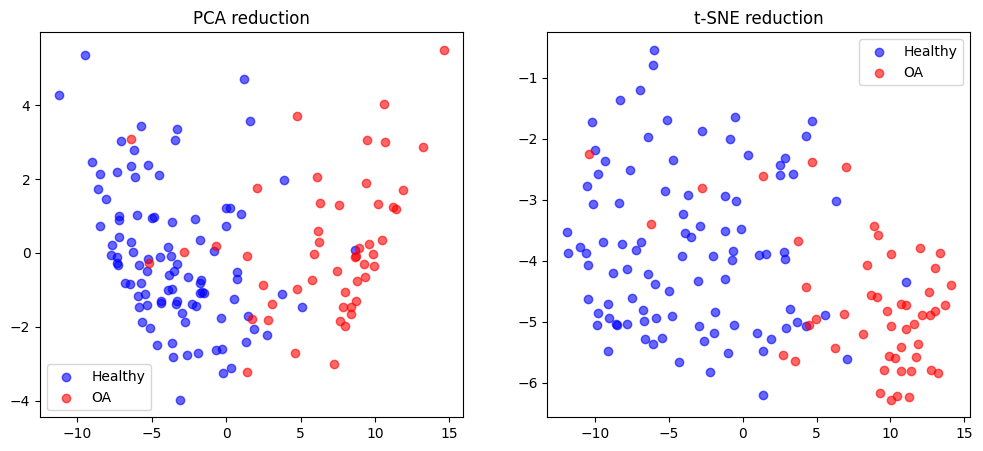

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for label, name, color in zip([0, 1], ['Healthy', 'OA'], ['blue', 'red']):
    mask = all_truth_labels == label
    ax1.scatter(
        pca_latents[mask, 0],
        pca_latents[mask, 1],
        label=name,
        color=color,
        alpha=0.6
    )
ax1.set_title("PCA reduction")
ax1.legend()

for label, name, color in zip([0, 1], ['Healthy', 'OA'], ['blue', 'red']):
    mask = all_truth_labels == label
    ax2.scatter(
        tsne_latents[mask, 0],
        tsne_latents[mask, 1],
        label=name,
        color=color,
        alpha=0.6
    )
ax2.set_title("t-SNE reduction")
ax2.legend()

plt.show()

### 4. Comparison of PCA and t-SNE
Looking at the PCA plot, the clusters are heavily overlapping and do not have a clear shape. Their representation seems very sparse and the root cause probably is the linear nature of PCA, which in this case does not give a useful representation.

Moving on to the t-SNE plot, the points are generally better separated, with just a few overlappings and clustering in more compact shapes, that is because t-SNE preserves local structures. There are, however, some points from the "OA" class which are grouped together with the "Healthy" class points. This may represent potential false negative samples, or a t-SNE projection distortion.

The poor visual representation in the PCA plot doesn't necessarily mean the model performs badly, it may simply reflect information loss during 2D projection from a 256-dimensional space. However, since the classes in the t-SNE plot present a more clear distinction, this tells us that the model has learned a good representation, which means it has learned to map different images into different regions of the latent space. Overall, t-SNE provides a more informative visualization then PCA for this latent space.

### 5. Inspection of misclassified samples

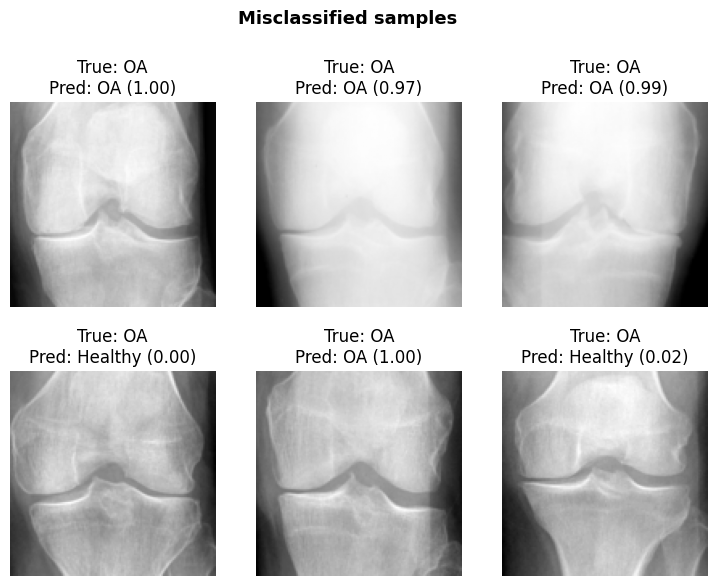

In [7]:
class_names = {0: "Healthy", 1: "OA"}

X_test_new = np.load("X_test.npy")

misclassified_mask = all_truth_labels != all_pred_labels
misclassified_idx  = np.where(misclassified_mask)[0]

misclassified = X_test_new[mask]
truth_labels = all_truth_labels[mask]
pred_labels = all_pred_labels[mask]
confidences = all_pred_conf[mask]

fig, axes = plt.subplots(2, 3,
    figsize=(3 * 3, 2 * 3.2))
axes = axes.flatten()
fig.suptitle("Misclassified samples", fontsize=13, fontweight="bold", y=1.01)
for i, idx in enumerate(misclassified_idx[:6]):
    true_label = truth_labels[i]
    pred = pred_labels[i]
    prob = confidences[i]

    ax = axes[i]
    ax.imshow(misclassified[i].squeeze(), cmap="gray")
    ax.set_title(
        f"True: {class_names[int(true_label)]}\n"
        f"Pred: {class_names[int(pred)]} ({prob:.2f})"
    )
    ax.axis("off")

plt.tight_layout
plt.show()

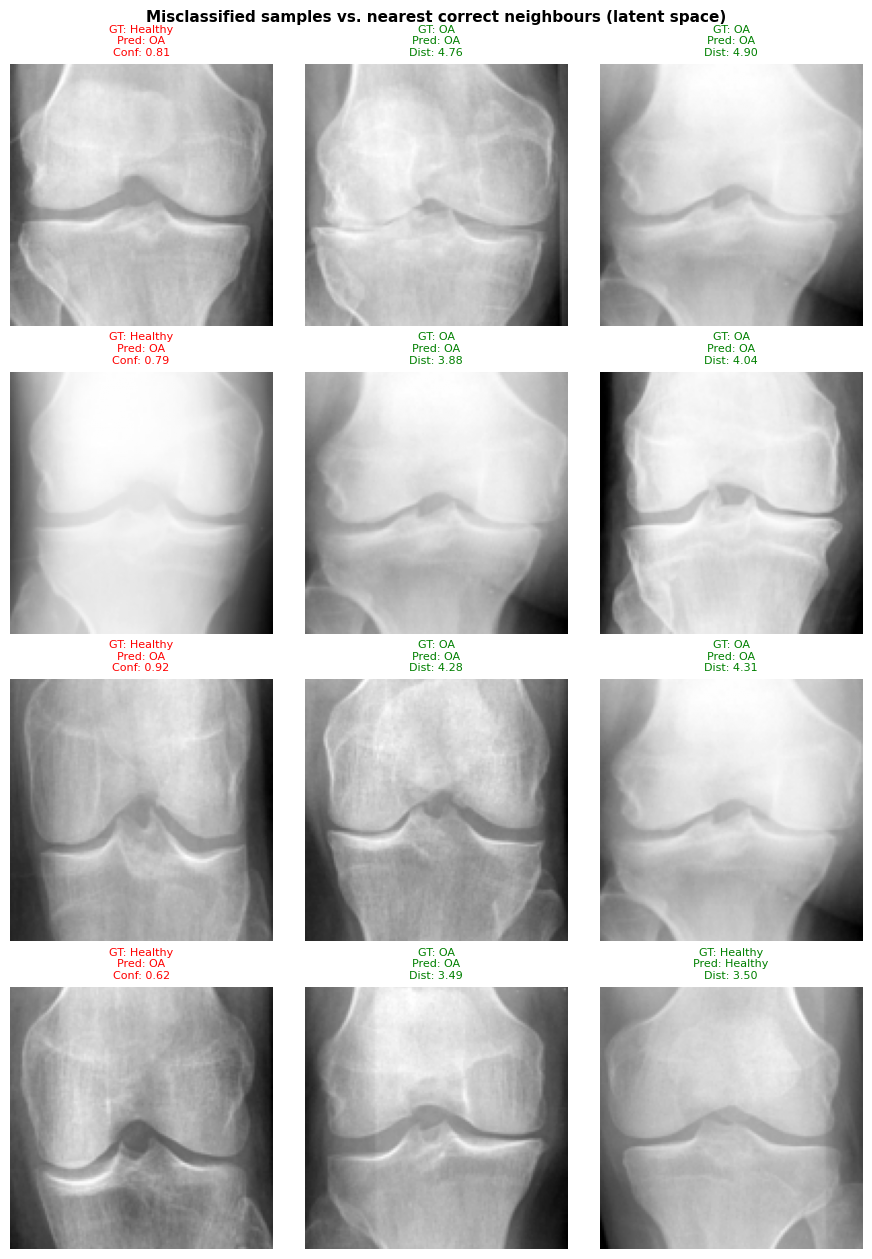

In [8]:
correct_mask = ~misclassified_mask
correct_idx = np.where(correct_mask)[0]

nbrs = NearestNeighbors(n_neighbors=2, metric="euclidean")
nbrs.fit(all_latents[correct_idx])

distances, neighbour_pos = nbrs.kneighbors(all_latents[misclassified_idx])
neighbour_global_idx = correct_idx[neighbour_pos]

N_COMPARE = min(4, len(misclassified_idx))
fig, axes = plt.subplots(N_COMPARE, 3,
    figsize=(3 * 3, N_COMPARE * 3.2))
fig.suptitle("Misclassified samples vs. nearest correct neighbours (latent space)",
             fontsize=11, fontweight="bold")

for row, mis_idx in enumerate(misclassified_idx[:N_COMPARE]):
    # left column: the misclassified image
    ax = axes[row, 0]
    ax.imshow(X_test_new[mis_idx].squeeze(), cmap="gray")
    ax.set_title(
        f"GT: {class_names[all_truth_labels[mis_idx]]}\n"
        f"Pred: {class_names[all_pred_labels[mis_idx]]}\n"
        f"Conf: {all_pred_conf[mis_idx]:.2f}",
        fontsize=8, color="red"
    )
    ax.axis("off")

    if row == 0:
        ax.set_xlabel("Misclassified", fontsize=9)

    # right columns: nearest correctly classified neighbours
    for col, (nb_idx, dist) in enumerate(zip(neighbour_global_idx[row], distances[row]), start=1):
        ax = axes[row, col]
        ax.imshow(X_test_new[nb_idx].squeeze(), cmap="gray")
        ax.set_title(
            f"GT: {class_names[all_truth_labels[nb_idx]]}\n"
            f"Pred: {class_names[all_pred_labels[nb_idx]]}\n"
            f"Dist: {dist:.2f}",
            fontsize=8, color="green"
        )
        ax.axis("off")
        if row == 0:
            ax.set_xlabel(f"Neighbour {col}", fontsize=9)

plt.tight_layout()
plt.show()

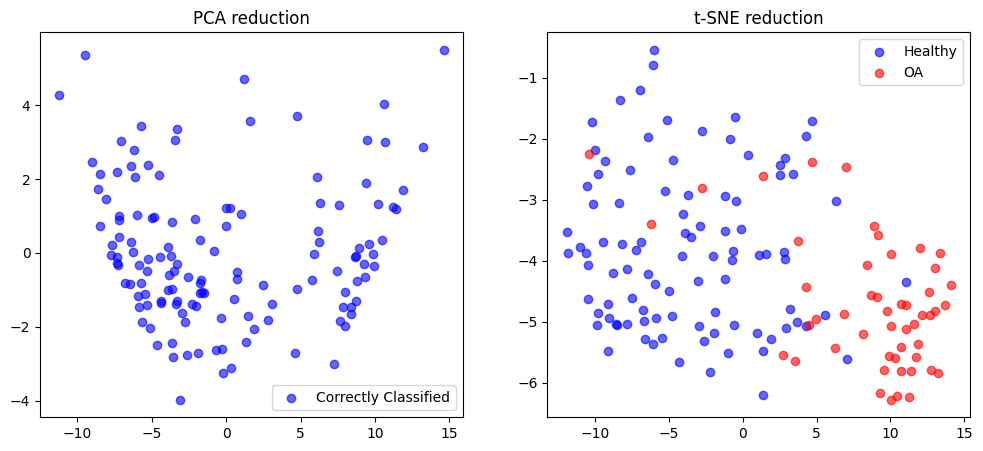

In [ ]:
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))

misclassified_mask = all_truth_labels != all_pred_labels
ax3.scatter(
    pca_latents[~misclassified_mask, 0],
    pca_latents[~misclassified_mask, 1],
    label="Correctly Classified",
    color="blue",
    alpha=0.6
)
ax3.set_title("PCA reduction")
ax3.legend()

for label, name, color in zip([0, 1], ['Healthy', 'OA'], ['blue', 'red']):
    mask = all_truth_labels == label
    ax4.scatter(
        tsne_latents[mask, 0],
        tsne_latents[mask, 1],
        label=name,
        color=color,
        alpha=0.6
    )
ax4.set_title("t-SNE reduction")
ax4.legend()

plt.show()

From the confidence values, we can see that the model is appropriately uncertain on the misclassified samples. This suggests the model knows which are the borderline cases; it is not confidently wrong, which would be much worse.
Raising the treshold, would make the model classify these samples correctly, but may also result in increasing the false negatives. This tradeoff is further discussed in the report.

Comparing the misclassified knees, they present an unusual bone structure with respect to their correctly classified neighbors, which may be an indicator on why the model is confusing them